t2tv2
hg38


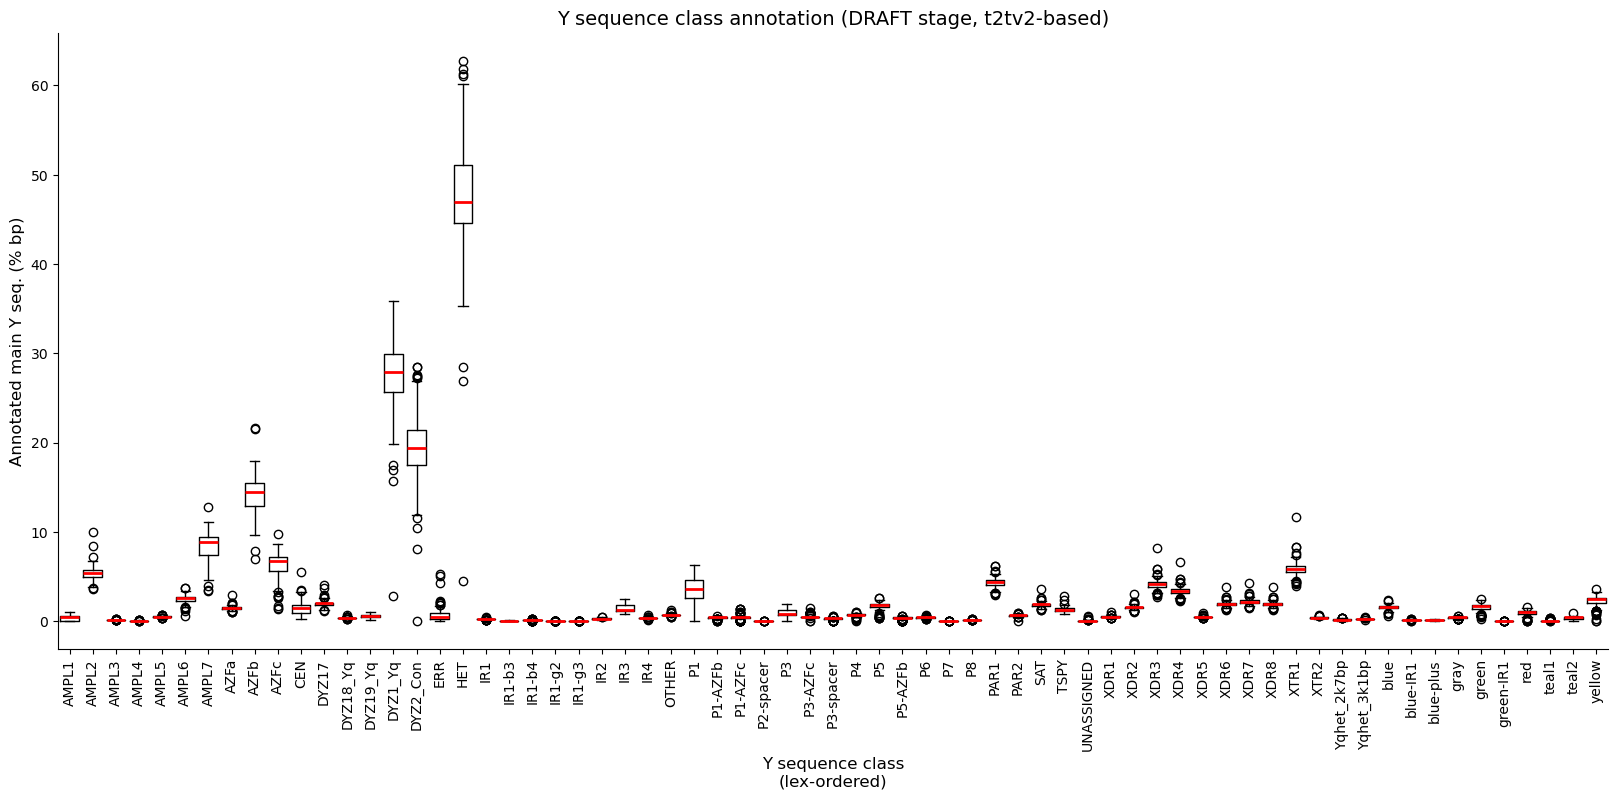

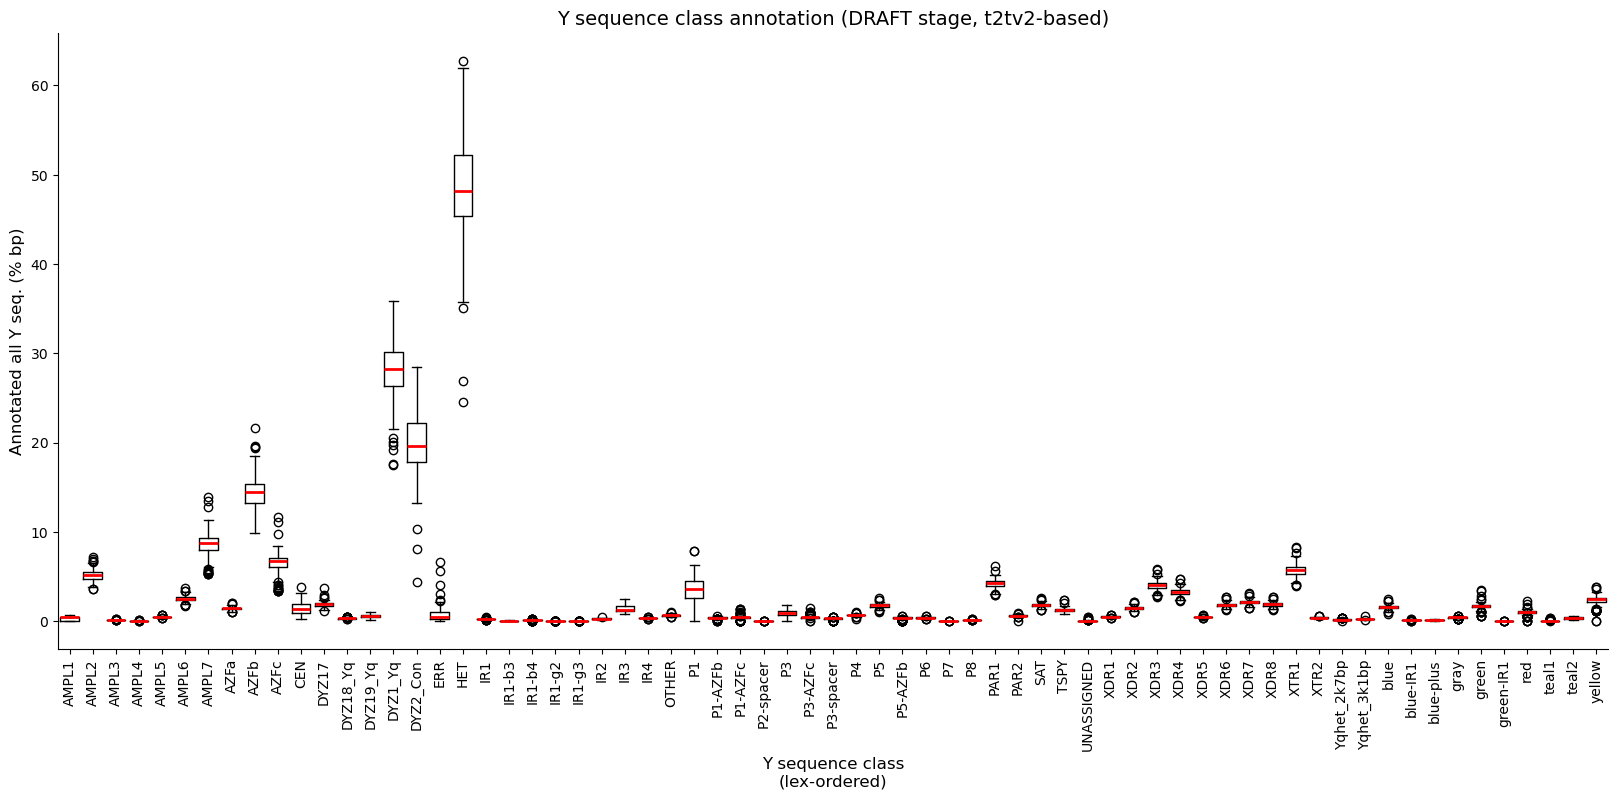

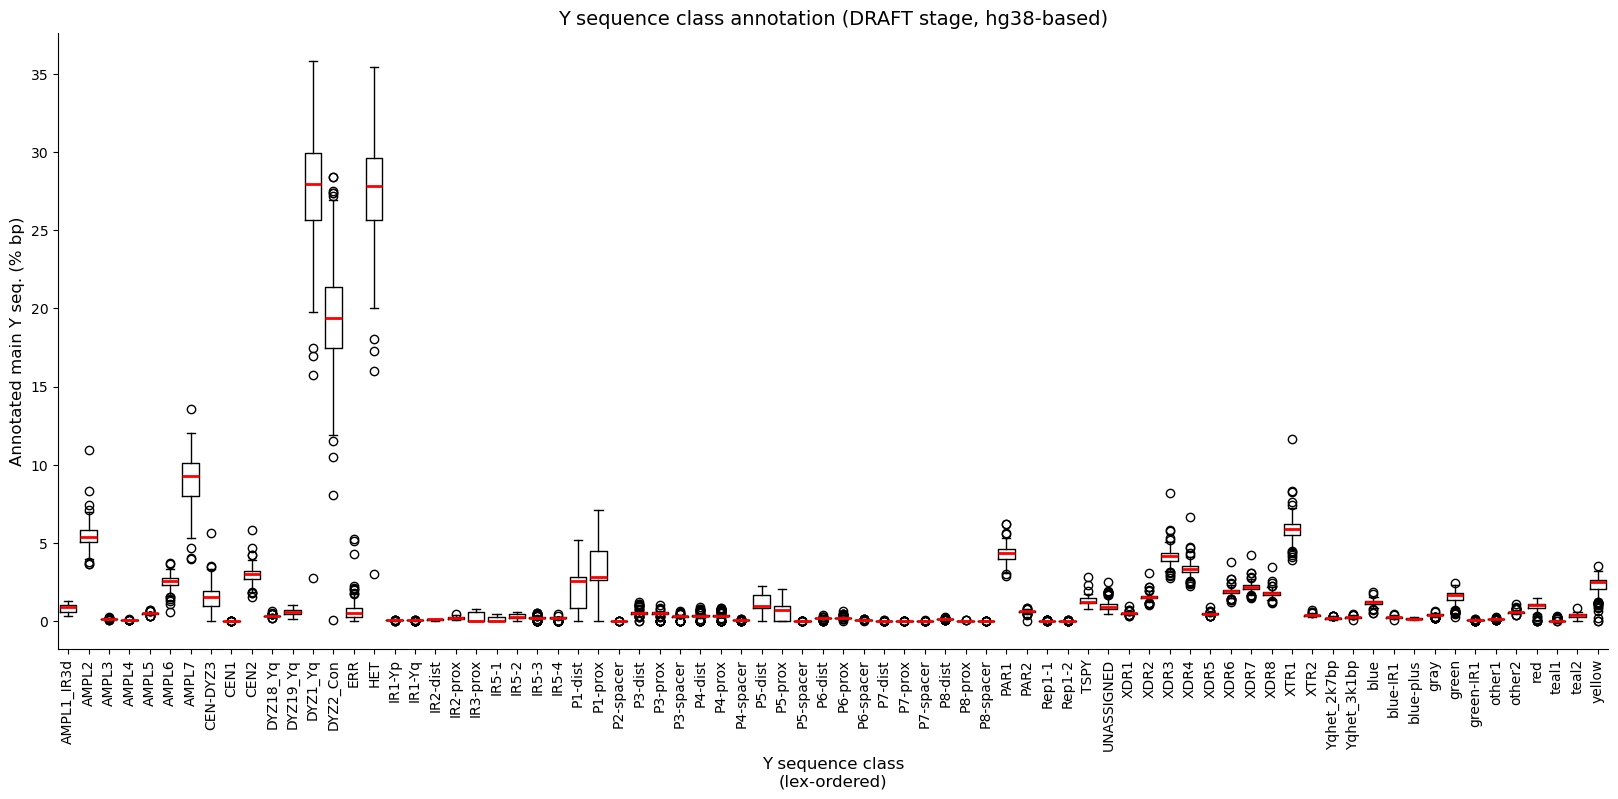

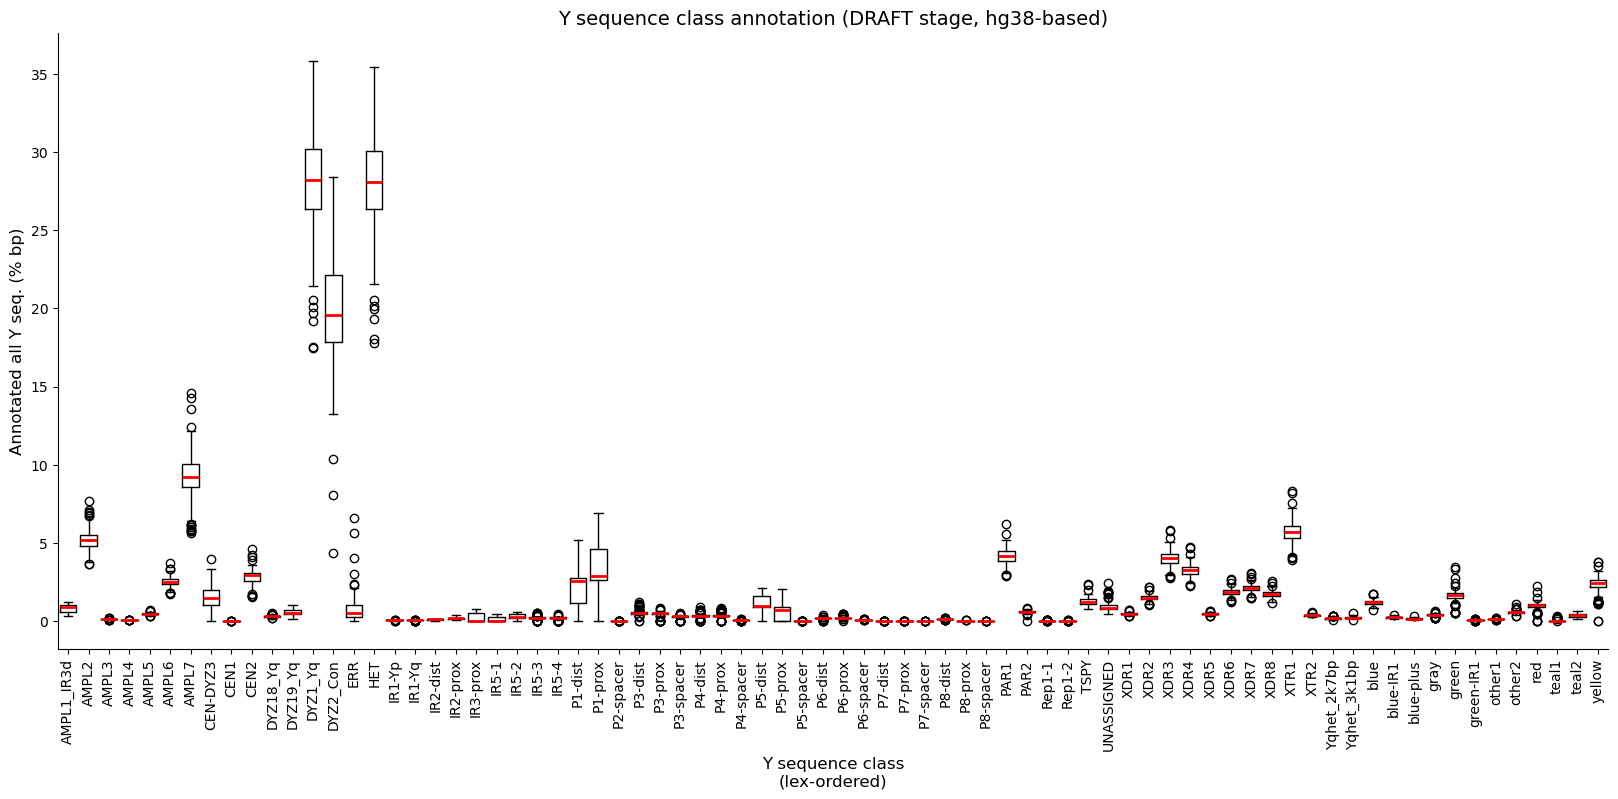

In [38]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

### NB-specific code

import re
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt



THIS_NB_DATA_ROOT = DATA_ROOT.joinpath("wf-data/region-labels/label_stats")


def simplify_color_block_labels(label):
    """This function is copied from the script
    PROJECT/codebase/postproc-region-labels/workflow/scripts/finalize_labels.py
    and MUST NOT be changed here.
    """
    colors = "(" + "|".join(["blue", "red", "green", "yellow", "gray"]) +")"
    mobj = re.search(colors, label)
    if mobj is None:
        return label
    s,e = mobj.span()
    color = label[s:e]
    qualifier = "(plus|IR[0-9])"
    mobj = re.search(qualifier, label)
    if mobj is not None:
        s, e = mobj.span()
        qual = label[s:e]
        new_label = f"{color}-{qual}"
    else:
        new_label = color
    return new_label


def compute_reference_annotation_stats(file_path, ref_label):

    df = pd.read_csv(file_path, sep="\t", header=0)
    df["length"] = df["end"] - df["start"]
    total_length = df["end"].max()
    df["base_label"] = df["seqclass"].apply(simplify_color_block_labels)
    # gen list of labels in chrom pos order
    label_order = []
    for row in df.itertuples():
        if row.base_label in label_order:
            continue
        label_order.append(row.base_label)
    agg = df.groupby(["#chrom", "base_label"])["length"].sum().reset_index(drop=False, inplace=False)
    agg["seq_length"] = total_length
    agg["pct_cov"] = (agg["length"] / agg["seq_length"] * 100).round(3)
    assert len(label_order) == df["base_label"].nunique()
    label_order.extend(["UNASSIGNED", "ERR"])
    return agg, label_order


def prep_data_for_plotting(collect_values, ref_label_order):

    plot_values = {}
    for sub_label in ["main", "all"]:
        sub_values = collect_values[sub_label]
        df = pd.concat(sub_values, axis=1, ignore_index=False)
        df.fillna(0, inplace=True)
        df = df.transpose()
        df.sort_index(axis=1, inplace=True)
        plot_values[sub_label] = df
    return plot_values


hg38_stats, hg38_order = compute_reference_annotation_stats(
    CONFIG["project_repo"].joinpath("annotation", "norm", "GRCh38-Y_regions_repeat-details.bed"),
    "hg38"
)
t2t_stats, t2t_order = compute_reference_annotation_stats(
    CONFIG["project_repo"].joinpath("annotation", "norm", "HG002-Y_T2Tv2_regions_repeat-details.bed"),
    "t2tv2"
)

ref_info = {
    "hg38_stats": hg38_stats,
    "hg38_order": hg38_order,
    "t2tv2_stats": t2t_stats,
    "t2tv2_order": t2t_order
}

annot_state = "DRAFT"
refs = ["t2tv2", "hg38"]

subset_select = [
    ("main", 0, "seq_pct_cov"),
    ("all", -1, "total_pct_cov")
]

for ref in refs:
    print(ref)
    all_table_files = list(THIS_NB_DATA_ROOT.glob(f"*{ref}*.tsv"))
    collect_values = {
        "main": [],
        "all": []
    }
    for table_file in all_table_files:
        sample = table_file.stem.split(".")[0]
        df = pd.read_csv(table_file, sep="\t", header=0)
        df["is_main"] = df["#seq"].str.endswith("_chrY").astype(int)
        for sub_label, sub_thres, sub_col in subset_select:
            label_stats = df.loc[
                df["is_main"] > sub_threshold,
                ["name", sub_col]
            ].groupby("name").first()
            label_stats.rename({sub_col: sample}, axis=1, inplace=True)
            collect_values[sub_label].append(label_stats)

    plot_values = prep_data_for_plotting(collect_values, ref_info[f"{ref}_order"])

    for sub_label, _, _ in subset_select:

        this_plot = plot_values[sub_label]
        fig, ax = plt.subplots(figsize=(20,8))

        plot_lines = ax.boxplot(
            this_plot,
            notch=False, sym=None, widths=0.8,
            tick_labels=this_plot.columns,
            meanline=False,
            medianprops={"color": "red", "lw": 2}
        )
        ax.tick_params(axis='x', labelrotation=90)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylabel(f"Annotated {sub_label} Y seq. (% bp)", fontsize=12)
        ax.set_xlabel("Y sequence class\n(lex-ordered)", fontsize=12)

        ax.set_title(f"Y sequence class annotation ({annot_state} stage, {ref}-based)", fontsize=14)
        
        # # add ref markers if applicable:
        # ref_labels = ref_info[f"{ref}_order"]
        # for ref_label in ref_labels:
        #     if ref_label not in this_plot.columns:
        #         print(ref_label)
        #         continue

 